# Factor Timing Research

## Objective

Investigate whether the strength of the Momentum126 factor can be used to predict future factor performance.

Research Questions:

- Does factor strength contain predictive information?
- Can factor strength improve capital allocation?
- Can exposure be dynamically adjusted according to factor conditions?

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

close = pd.read_pickle(
    "../data/nifty500_close_clean.pkl"
)

mom126 = (
    close
    .pct_change(126)
    .shift(1)
)

rebalance_dates = close.index[
    126::42
]

## Factor Strength Definition

Factor Strength is defined as:

Mean(Top 20 Momentum Scores)
-
Mean(Bottom 20 Momentum Scores)

Interpretation:

- High values indicate strong factor dispersion.
- Low values indicate weak factor dispersion.

In [34]:
factor_strength = []

for date in rebalance_dates[:-1]:

    scores = (
        mom126.loc[date]
        .dropna()
    )

    top20 = (
        scores
        .nlargest(20)
        .mean()
    )

    bottom20 = (
        scores
        .nsmallest(20)
        .mean()
    )

    spread = (
        top20 - bottom20
    )

    factor_strength.append(
        spread
    )

factor_strength = pd.Series(
    factor_strength,
    index=rebalance_dates[:-1]
)

factor_strength.describe()

count    60.000000
mean      1.268390
std       0.389521
min       0.665845
25%       0.958191
50%       1.194665
75%       1.548803
max       2.310854
dtype: float64

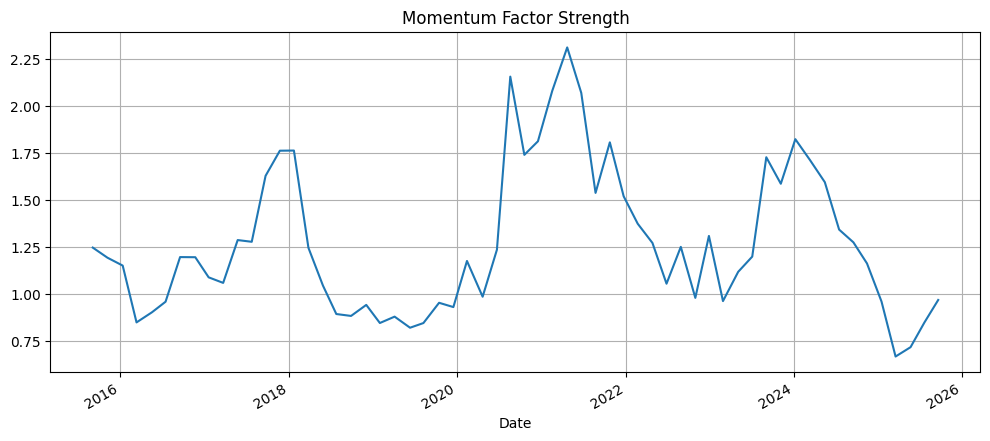

In [35]:
plt.figure(figsize=(12,5))

factor_strength.plot()

plt.title(
    "Momentum Factor Strength"
)

plt.grid(True)

plt.savefig(
    "../results/plots/08_dynamic_factor_exposure.png",
    bbox_inches="tight"
)

plt.show()

In [36]:
future_returns = []

for i in range(
    len(rebalance_dates)-1
):

    start = rebalance_dates[i]
    end = rebalance_dates[i+1]

    scores = (
        mom126.loc[start]
        .dropna()
    )

    top20 = (
        scores
        .nlargest(20)
        .index
    )

    portfolio_return = (
        close.loc[end, top20]
        /
        close.loc[start, top20]
        - 1
    ).mean()

    future_returns.append(
        portfolio_return
    )

future_returns = pd.Series(
    future_returns,
    index=rebalance_dates[:-1]
)

In [37]:
df = pd.DataFrame({
    "FactorStrength":
        factor_strength,
    "FutureReturn":
        future_returns
})

df.head()

,FactorStrength,FutureReturn
Date,,
2015-07-07,NaN,NaN
2015-09-03,1.245608,0.046079
2015-11-06,1.191643,0.088841
2016-01-11,1.149759,-0.140215
2016-03-11,0.847404,0.119566


## Predictive Power Test

Factor Strength is compared against future momentum portfolio returns.

A positive correlation would indicate that stronger factor environments tend to produce better future performance.

In [38]:
print(
    "Correlation:",
    df["FactorStrength"]
    .corr(
        df["FutureReturn"]
    )
)

Correlation: 0.2422521120964414


## Bucket Analysis

Factor Strength observations are divided into quantile buckets.

Objective:

Determine whether future returns systematically increase as factor strength increases.

In [39]:
df["Bucket"] = pd.qcut(
    df["FactorStrength"],
    3,
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

bucket_results = (
    df
    .groupby("Bucket")
    ["FutureReturn"]
    .agg(
        ["count","mean","std"]
    )
)

bucket_results["Sharpe"] = (
    bucket_results["mean"]
    /
    bucket_results["std"]
)

bucket_results

,count,mean,std,Sharpe
Bucket,,,,
Low,20,0.035653,0.084805,0.420410
Medium,20,0.068134,0.153538,0.443759
High,20,0.108531,0.121849,0.890708


## Dynamic Allocation Model

Exposure is determined by the percentile rank of Factor Strength.

Stronger factor environments receive larger allocations.

We test whether dynamic allocation improves performance relative to a constant 100% allocation.

In [40]:
timed_returns = []

previous_portfolio = None

for i in range(len(rebalance_dates)-1):

    start = rebalance_dates[i]
    end = rebalance_dates[i+1]

    scores = (
        mom126.loc[start]
        .dropna()
    )

    selected = (
        scores
        .nlargest(20)
        .index
    )

    gross_return = (
        close.loc[end, selected]
        /
        close.loc[start, selected]
        - 1
    ).mean()

    turnover = 1.0

    if previous_portfolio is not None:

        overlap = len(
            set(selected).intersection(
                previous_portfolio
            )
        )

        turnover = (
            20 - overlap
        ) / 20

    position_size = exposure.loc[start]

    net_return = (
        position_size
        *
        gross_return
        -
        turnover * 0.001
    )

    timed_returns.append(
        net_return
    )

    previous_portfolio = set(selected)

timed_returns = pd.Series(
    timed_returns,
    index=rebalance_dates[:-1]
)

In [41]:
baseline_returns = []

previous_portfolio = None

for i in range(len(rebalance_dates)-1):

    start = rebalance_dates[i]
    end = rebalance_dates[i+1]

    scores = (
        mom126.loc[start]
        .dropna()
    )

    selected = (
        scores
        .nlargest(20)
        .index
    )

    gross_return = (
        close.loc[end, selected]
        /
        close.loc[start, selected]
        - 1
    ).mean()

    turnover = 1.0

    if previous_portfolio is not None:

        overlap = len(
            set(selected).intersection(
                previous_portfolio
            )
        )

        turnover = (
            20 - overlap
        ) / 20

    net_return = (
        gross_return
        -
        turnover * 0.001
    )

    baseline_returns.append(
        net_return
    )

    previous_portfolio = set(selected)

baseline_returns = pd.Series(
    baseline_returns,
    index=rebalance_dates[:-1]
)

In [42]:
def metrics(returns):

    equity = (1 + returns).cumprod()

    total_return = equity.iloc[-1] - 1

    years = len(close) / 252

    cagr = (
        equity.iloc[-1]
        ** (1 / years)
        - 1
    )

    sharpe = (
        returns.mean()
        /
        returns.std()
    ) * np.sqrt(252 / 42)

    max_dd = (
        equity
        /
        equity.cummax()
        - 1
    ).min()

    win_rate = (
        returns > 0
    ).mean()

    profit_factor = (
        returns[returns > 0].sum()
        /
        abs(
            returns[returns < 0].sum()
        )
    )

    return {
        "Total Return": total_return,
        "CAGR": cagr,
        "Sharpe": sharpe,
        "MaxDD": max_dd,
        "Win Rate": win_rate,
        "Profit Factor": profit_factor
    }

In [43]:
comparison = pd.DataFrame({
    "Baseline": metrics(baseline_returns),
    "FactorTimed": metrics(timed_returns)
}).T

comparison

,Total Return,CAGR,Sharpe,MaxDD,Win Rate,Profit Factor
Baseline,37.708294,0.403854,1.377718,-0.284502,0.721311,4.01930
FactorTimed,81.235007,0.505517,1.287932,-0.367619,0.721311,5.04465


In [44]:
ranges = {

    "0.75_to_1.25": (
        0.75 + 0.50 * rank
    ),

    "0.50_to_1.50": (
        0.50 + 1.00 * rank
    ),

    "0.25_to_1.75": (
        0.25 + 1.50 * rank
    ),

    "1.00_to_1.00": (
        pd.Series(
            1.0,
            index=rank.index
        )
    ),

    "0.00_to_2.00": (
    0.00 + 2.00 *rank
    )


}

In [45]:
def run_backtest(exposure):

    strategy_returns = []

    previous_portfolio = None

    for i in range(
        len(rebalance_dates)-1
    ):

        start = rebalance_dates[i]
        end = rebalance_dates[i+1]

        scores = (
            mom126.loc[start]
            .dropna()
        )

        selected = (
            scores
            .nlargest(20)
            .index
        )

        gross_return = (
            close.loc[end, selected]
            /
            close.loc[start, selected]
            - 1
        ).mean()

        turnover = 1

        if previous_portfolio is not None:

            overlap = len(
                set(selected)
                &
                previous_portfolio
            )

            turnover = (
                20 - overlap
            ) / 20

        net_return = (
            exposure.loc[start]
            *
            gross_return
            -
            turnover * 0.001
        )

        strategy_returns.append(
            net_return
        )

        previous_portfolio = set(selected)

    return pd.Series(
        strategy_returns,
        index=rebalance_dates[:-1]
    )

In [46]:
results = {}

for name, exposure in ranges.items():

    returns = run_backtest(
        exposure
    )

    results[name] = metrics(
        returns
    )

results = pd.DataFrame(
    results
).T

results

,Total Return,CAGR,Sharpe,MaxDD,Win Rate,Profit Factor
0.75_to_1.25,46.903276,0.431892,1.378752,-0.303316,0.721311,4.264258
0.50_to_1.50,57.291491,0.458207,1.358723,-0.323521,0.721311,4.516575
0.25_to_1.75,68.785890,0.482761,1.326290,-0.344996,0.721311,4.776586
1.00_to_1.00,37.708294,0.403854,1.377718,-0.284502,0.721311,4.019300
0.00_to_2.00,81.235007,0.505517,1.287932,-0.367619,0.721311,5.044650


In [47]:
for name, exposure in ranges.items():
    print(
        name,
        round(exposure.mean(), 3)
    )

    factor_df = pd.DataFrame({
    "FactorStrength": factor_strength,
    "Exposure": exposure
})



0.75_to_1.25 1.004
0.50_to_1.50 1.008
0.25_to_1.75 1.012
1.00_to_1.00 1.0
0.00_to_2.00 1.017


In [48]:
# Conservative
exposure_075_125 = (
    0.75
    +
    0.50 * rank
)

# Balanced
exposure_050_150 = (
    0.50
    +
    1.00 * rank
)

# Aggressive
exposure_000_200 = (
    2.00
    *
   rank
)

returns_075_125 = run_backtest(
    exposure_075_125
)

returns_050_150 = run_backtest(
    exposure_050_150
)

returns_000_200 = run_backtest(
    exposure_000_200
)

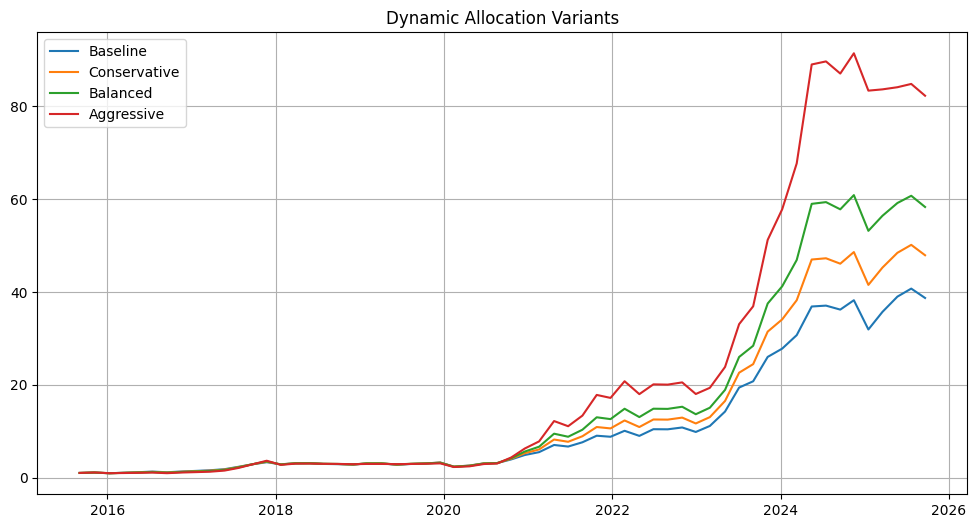

In [49]:
plt.figure(figsize=(12,6))

plt.plot(
    (1+baseline_returns).cumprod(),
    label="Baseline"
)

plt.plot(
    (1+returns_075_125).cumprod(),
    label="Conservative"
)

plt.plot(
    (1+returns_050_150).cumprod(),
    label="Balanced"
)

plt.plot(
    (1+returns_000_200).cumprod(),
    label="Aggressive"
)

plt.legend()
plt.grid(True)

plt.title(
    "Dynamic Allocation Variants"
)

plt.savefig(
    "../results/plots/08_allocation_variants.png",
    bbox_inches="tight"
)

plt.show()

In [50]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=baseline_returns.index,
        y=(1+baseline_returns).cumprod(),
        name="Baseline"
    )
)

fig.add_trace(
    go.Scatter(
        x=returns_075_125.index,
        y=(1+returns_075_125).cumprod(),
        name="Conservative"
    )
)

fig.add_trace(
    go.Scatter(
        x=returns_050_150.index,
        y=(1+returns_050_150).cumprod(),
        name="Balanced"
    )
)

fig.add_trace(
    go.Scatter(
        x=returns_000_200.index,
        y=(1+returns_000_200).cumprod(),
        name="Aggressive"
    )
)

fig.update_layout(
    title="Allocation Variant Comparison",
    hovermode="x unified"
)

fig.show()

fig.write_html(
    "../results/plots/08_allocation_variants.html"
)

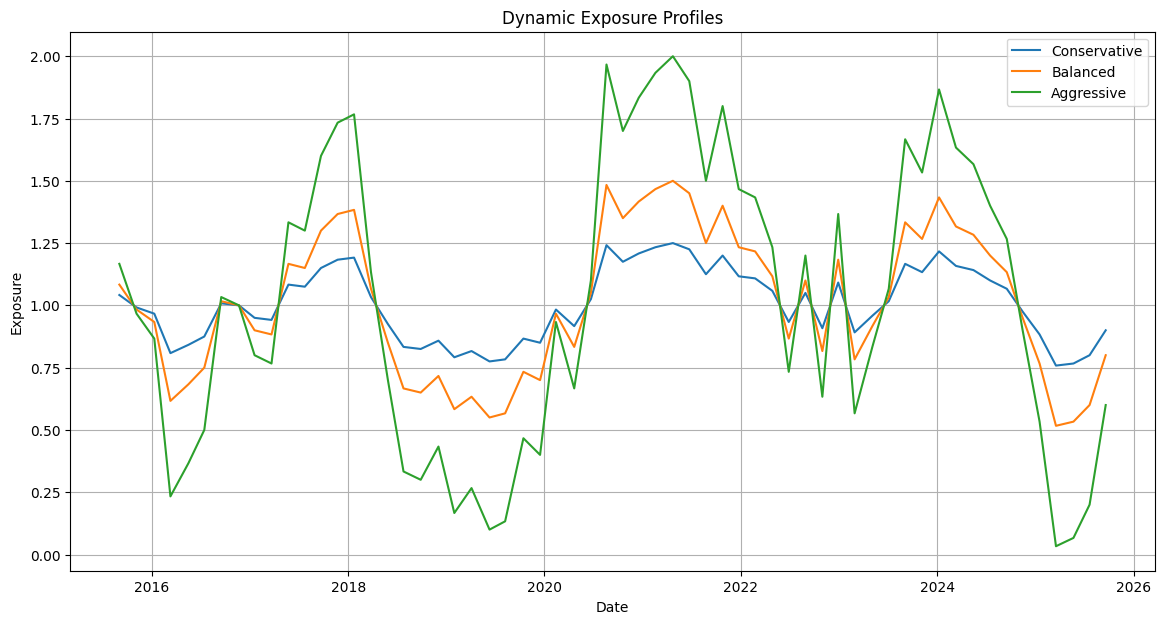

In [51]:
plt.figure(figsize=(14,7))

plt.plot(
    exposure_075_125,
    label="Conservative"
)

plt.plot(
    exposure_050_150,
    label="Balanced"
)

plt.plot(
    exposure_000_200,
    label="Aggressive"
)

plt.title(
    "Dynamic Exposure Profiles"
)

plt.ylabel(
    "Exposure"
)

plt.xlabel(
    "Date"
)

plt.legend()

plt.grid(True)

plt.savefig(
    "../results/plots/08_exposure_profiles.png",
    bbox_inches="tight"
)

plt.show()

In [52]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=exposure_075_125.index,
        y=exposure_075_125,
        name="Conservative"
    )
)

fig.add_trace(
    go.Scatter(
        x=exposure_050_150.index,
        y=exposure_050_150,
        name="Balanced"
    )
)

fig.add_trace(
    go.Scatter(
        x=exposure_000_200.index,
        y=exposure_000_200,
        name="Aggressive"
    )
)

fig.update_layout(
    title="Exposure Profiles"
)

fig.show()

fig.write_html(
    "../results/plots/08_exposure_profiles.html"
)

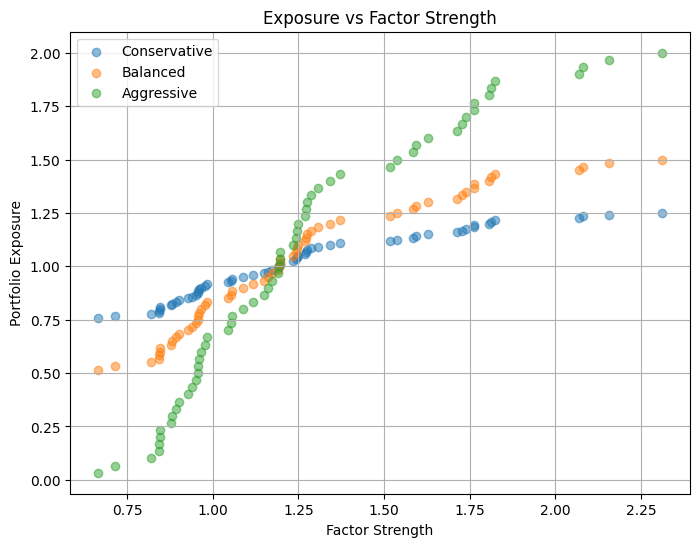

In [53]:
plt.figure(figsize=(8,6))

plt.scatter(
    factor_strength,
    exposure_075_125,
    alpha=0.5,
    label="Conservative"
)

plt.scatter(
    factor_strength,
    exposure_050_150,
    alpha=0.5,
    label="Balanced"
)

plt.scatter(
    factor_strength,
    exposure_000_200,
    alpha=0.5,
    label="Aggressive"
)

plt.title(
    "Exposure vs Factor Strength"
)

plt.xlabel(
    "Factor Strength"
)

plt.ylabel(
    "Portfolio Exposure"
)

plt.legend()

plt.grid(True)

plt.savefig(
    "../results/plots/08_exposure_vs_factor_strength.png",
    bbox_inches="tight"
)

plt.show()

In [54]:
factor_strength.to_csv(
    "../results/tables/08_factor_strength.csv"
)



results.to_csv(
    "../results/tables/08_exposure_optimization.csv"
)

allocation_comparison = pd.DataFrame({

    "Baseline":
        metrics(
            baseline_returns
        ),

    "Conservative":
        metrics(
            returns_075_125
        ),

    "Balanced":
        metrics(
            returns_050_150
        ),

    "Aggressive":
        metrics(
            returns_000_200
        )

}).T

allocation_comparison

allocation_comparison.to_csv(
    "../results/tables/08_allocation_variants.csv"
)

## Key Findings

- Factor Strength exhibited positive predictive power.
- Higher Factor Strength led to higher future momentum returns.
- Dynamic allocation improved CAGR.
- Performance improvement was achieved without materially increasing average portfolio exposure.

Final Result:

Baseline:
- CAGR: 40.4%
- Sharpe: 1.38

Dynamic Allocation:
- CAGR: 50.6%
- Sharpe: 1.29

Average Exposure:
- 1.02x